# Full-Dataset Baseline Similarity Pipeline

This notebook builds the revised project pipeline for the Alexa skill-squatting analysis.

Instead of computing similarity only inside a sampled subset, this notebook computes baseline risk features over the full cleaned UQ-AAS21 dataset, then selects an LLM analysis subset from multiple buckets:

- baseline high-risk skills
- baseline medium-risk skills
- baseline low-risk controls
- high genericity / ambiguous invocation names
- high-popularity skills from sensitive categories
- random category-balanced controls

The output CSVs can be used as the traditional rule-based baseline against which the LLM vulnerability analysis is compared.

In [39]:
from pathlib import Path
import itertools
import math
import re
import string
from collections import Counter, defaultdict
import openpyxl

import numpy as np
import pandas as pd
import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

In [40]:
# Input files
PART_I = Path("UQ-AAS21-I.xlsx")
PART_II = Path("UQ-AAS21-II.xlsx")

# Output files
FULL_CLEANED_OUT = Path("full_cleaned_alexa_skills.csv")
BASELINE_OUT = Path("full_alexa_skills_with_baselines.csv")
LLM_SUBSET_OUT = Path("llm_analysis_subset.csv")
TOP_LEXICAL_PAIRS_OUT = Path("top_lexical_pairs.csv")
TOP_PHONETIC_PAIRS_OUT = Path("top_phonetic_pairs.csv")
TOP_WORD_SQUAT_PAIRS_OUT = Path("top_word_squat_pairs.csv")
PHONETIC_CLUSTERS_OUT = Path("phonetic_clusters.csv")
CATEGORY_SUMMARY_OUT = Path("category_risk_summary.csv")

RANDOM_STATE = 42

# Similarity thresholds. Can be tuned!! 
LEXICAL_CLOSE_THRESHOLD = 0.80
PHONETIC_CLOSE_THRESHOLD = 0.85
NEIGHBORS_PER_SKILL = 15

# maximum number of pairs to consider for each analysis type 
MAX_PAIR_ROWS = 50000

# Word-squatting caps keep highly generic deletion signatures from creating accidental all-pairs work
MAX_SIGNATURE_GROUP_SIZE = 200
MAX_WORD_SQUAT_CANDIDATES_PER_SKILL = 100


## 1. Load And Clean The Full Dataset

The original Excel files have a blank first row and headers on the second row, so `header=1` is required.

In [41]:
df1 = pd.read_excel(PART_I, header=1)
df2 = pd.read_excel(PART_II, header=1)

print("Part I:", df1.shape)
print("Part II:", df2.shape)
print("Part I columns:", list(df1.columns))
print("Part II columns:", list(df2.columns))

Part I: (65195, 45)
Part II: (65195, 7)
Part I columns: ['Index', 'Skill Name', 'Skill Path', 'Developers', 'Average Rating', 'Number of Rating', 'Price', 'In-Skill Purchases', 'Wake-Up Words', 'Unnamed: 9', 'Unnamed: 10', 'Icon link', 'Category', 'Supported Languages', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44']
Part II columns: ['Index', 'Skill Path', 'Access', 'Invocation Name', 'Description', 'Developer Privacy Policy', 'Developer Terms of Use']


In [42]:
# Basic cleanup and merge.
df1 = df1.copy()
df2 = df2.copy()

df1["Skill Name"] = df1["Skill Name"].astype(str).str.strip()

# Keep Skill Path from df1 to avoid duplicate columns after merging.
if "Skill Path" in df2.columns:
    df2 = df2.drop(columns=["Skill Path"])

df1 = df1.rename(columns={"Wake-up Words": "Wake-up Words 1", "Unnamed: 9": "Wake-up Words 2", "Unnamed: 10": "Wake-up Words 3", "Supported Languages": "Unnamed: 13", "Unnamed: 15": "Supported Languages"})
unnamed_cols = [col for col in df1.columns if 'Unnamed' in col]
df1 = df1.drop(columns=unnamed_cols)

full_df = pd.merge(df1, df2, on="Index", how="inner")

full_df = full_df[full_df['Supported Languages'] == 'English'].copy()
full_df = full_df.drop(columns=["Supported Languages"])
full_df = full_df[full_df["Invocation Name"].notna()].copy()
full_df = full_df[full_df["Invocation Name"] != "Not Exists"].copy()
full_df = full_df.drop_duplicates(subset=["Skill Path"], keep="first").reset_index(drop=True)

# Preserve the manual correction from the original notebook.
full_df.loc[full_df["Skill Name"] == "Cork Ornaments", "Average Rating"] = "2.7 out of 5"

print("Full cleaned rows:", full_df.shape[0])
print("Full cleaned columns:", full_df.shape[1])
full_df.head()

Full cleaned rows: 42202
Full cleaned columns: 18


,Index,Skill Name,Skill Path,Developers,Average Rating,Number of Rating,Price,In-Skill Purchases,Wake-Up Words,Wake-up Words 2,Wake-up Words 3,Icon link,Category,Access,Invocation Name,Description,Developer Privacy Policy,Developer Terms of Use
0,1,Unofficial Ripple (XRP) Ticker,https://www.amazon.com/Newhouse-Unofficial-Rip...,by Newhouse,3.6 out of 5,5,Free to Enable,NaN,"“Alexa, ask Unofficial Ripple the current price.”","“Alexa, ask Unofficial Ripple for today's price.”","“Alexa, ask Unofficial Ripple the current rate.”",https://images-na.ssl-images-amazon.com/images...,Business & Finance,No permission needed,unofficial ripple,Gets the current USD exchange rate for the Rip...,Not Exists,Not Exists
1,2,Michael Braddon,https://www.amazon.com/IGNITE360-Michael-Bradd...,by IGNITE360,no rating,0,Free to Enable,NaN,"“Alexa, open michael braddon estate agent”","“Alexa, open michael braddon estate agent for ...","“Alexa, open michael braddon estate agent for ...",https://images-na.ssl-images-amazon.com/images...,Business & Finance,No permission needed,michael braddon estate agent,Michael Braddon is an estate agent with Blacks...,https://ignite360.com/privacy-policy/,https://ignite360.com/terms-and-conditions/
2,5,Krypto Kwote,https://www.amazon.com/SweetCat-Krypto-Kwote/d...,by SweetCat,4 out of 5,1,Free to Enable,NaN,“Alexa ask Crypto Quote how much Bitcoin costs”,“Alexa ask Crypto Quote what Ethereum costs”,“Alexa ask Crypto Quote how much Litecoin I ca...,https://images-na.ssl-images-amazon.com/images...,Business & Finance,No permission needed,crypto quote,This skill uses a public API to retrieve the p...,Not Exists,Not Exists
3,9,Ellie the health insurance digital assistant,https://www.amazon.com/Ellie-health-insurance-...,by Explain.Care Inc.,5 out of 5,1,Free to Enable,NaN,“Alexa open Ellie cares”,"“Alexa, open Inside Medical Assisting”","“Alexa, open medical coding Trivia”",https://images-na.ssl-images-amazon.com/images...,Business & Finance,No permission needed,ellie cares,"Ellie, our digital assistant, is ready to help...",https://www.explain.care/privacy-policy,https://www.explain.care/terms-of-use
4,11,General Contractor,https://www.amazon.com/APPS-Developer-Dot-Ca-I...,by APPS Developer Dot Ca Inc.,1 out of 5,1,Free to Enable,NaN,"“Alexa, open General Contractor”","“Alexa, start General Contractor”","“Alexa, launch General Contractor”",https://images-na.ssl-images-amazon.com/images...,Business & Finance,No permission needed,general contractor,General Contractor is a skill to help you lear...,https://appsdeveloper.ca/alexa-privacy-policy/,Not Exists


## 2. Normalize Invocation Names And Add Existing Preprocessing Features

These features include popularity, token genericity, invocation length, and the existing genericity-based ambiguity score. This score is not a pairwise similarity baseline; it captures short, common, generic invocation names.

In [43]:
def normalize_text(value):
    """Lowercase, remove punctuation-like characters, and collapse whitespace."""
    if pd.isna(value):
        return ""
    text = str(value).lower()
    text = text.replace("&", " and ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def parse_average_rating(rating_str):
    if pd.isna(rating_str) or rating_str == "no rating":
        return 0.0
    try:
        return float(str(rating_str).split(" ")[0])
    except ValueError:
        return 0.0


def assign_popularity_tier(n):
    if n == 0:
        return "unrated"
    if n < 10:
        return "very_low"
    if n < 100:
        return "low"
    if n < 1000:
        return "medium"
    return "high"

full_df["normalized_invocation"] = full_df["Invocation Name"].apply(normalize_text)
full_df = full_df[full_df["normalized_invocation"] != ""].copy().reset_index(drop=True)
full_df["invocation_tokens"] = full_df["normalized_invocation"].str.split()
full_df["invocation_length"] = full_df["invocation_tokens"].apply(len)

full_df["Average Rating"] = full_df["Average Rating"].apply(parse_average_rating)
full_df["Number of Rating"] = (
    full_df["Number of Rating"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
full_df["Number of Rating"] = pd.to_numeric(
    full_df["Number of Rating"], errors="coerce"
).fillna(0).astype(int)

full_df["popularity_score"] = full_df["Average Rating"] * full_df["Number of Rating"]
full_df["popularity_tier"] = full_df["Number of Rating"].apply(assign_popularity_tier)

print(full_df[["Skill Name", "Invocation Name", "normalized_invocation", "Category"]].head().to_string(index=False))

                                  Skill Name              Invocation Name        normalized_invocation           Category
              Unofficial Ripple (XRP) Ticker            unofficial ripple            unofficial ripple Business & Finance
                             Michael Braddon michael braddon estate agent michael braddon estate agent Business & Finance
                                Krypto Kwote                 crypto quote                 crypto quote Business & Finance
Ellie the health insurance digital assistant                  ellie cares                  ellie cares Business & Finance
                          General Contractor           general contractor           general contractor Business & Finance


In [44]:
# Genericity / ambiguity features from the original preprocessing idea, computed over the full cleaned dataset.
count_vectorizer = CountVectorizer(stop_words="english")
count_matrix = count_vectorizer.fit_transform(full_df["normalized_invocation"])
token_counts = np.asarray(count_matrix.sum(axis=0)).ravel()
tokens = count_vectorizer.get_feature_names_out()
token_freq = dict(zip(tokens, token_counts))


def genericity_score(text):
    words = text.split()
    if not words:
        return 0.0
    return float(np.mean([token_freq.get(w, 0) for w in words]))

full_df["genericity_score"] = full_df["normalized_invocation"].apply(genericity_score)
full_df["short_name_score"] = 1 / (full_df["invocation_length"] + 1)
full_df["genericity_ambiguity_score"] = (
    full_df["genericity_score"] * 0.7 + full_df["short_name_score"] * 0.3
)

min_amb = full_df["genericity_ambiguity_score"].min()
max_amb = full_df["genericity_ambiguity_score"].max()
if max_amb > min_amb:
    full_df["norm_genericity_ambiguity_score"] = (
        full_df["genericity_ambiguity_score"] - min_amb
    ) / (max_amb - min_amb)
else:
    full_df["norm_genericity_ambiguity_score"] = 0.0



# Exact invocation-name collisions are a distinct risk signal from near-neighbor squatting.
# Example: many unique skills may all use the exact same invocation name, such as "space facts".
exact_invocation_group_size = full_df.groupby("normalized_invocation")["normalized_invocation"].transform("size")
full_df["exact_invocation_group_size"] = exact_invocation_group_size.astype(int)
full_df["exact_invocation_collision_count"] = (exact_invocation_group_size - 1).astype(int)
full_df["has_exact_invocation_collision"] = full_df["exact_invocation_collision_count"] > 0

full_df.to_csv(FULL_CLEANED_OUT, index=False)
print("Wrote", FULL_CLEANED_OUT, full_df.shape)
full_df[["Invocation Name", "genericity_score", "invocation_length", "genericity_ambiguity_score"]].head()

Wrote full_cleaned_alexa_skills.csv (42202, 30)


,Invocation Name,genericity_score,invocation_length,genericity_ambiguity_score
0,unofficial ripple,72.0,2,50.50
1,michael braddon estate agent,46.5,4,32.61
2,crypto quote,123.0,2,86.20
3,ellie cares,2.5,2,1.85
4,general contractor,15.0,2,10.60


## 3. Lexical Similarity Baseline

This uses character n-gram TF-IDF and nearest-neighbor cosine similarity. Character n-grams catch small spelling edits, added punctuation/spacing effects, and near-identical invocation names without doing an expensive all-pairs edit-distance comparison.

In [45]:
# Compute lexical nearest neighbors over UNIQUE normalized invocation names.
# This prevents exact duplicate invocation names from dominating near-neighbor metrics.
unique_invocations_df = (
    full_df[["normalized_invocation"]]
    .drop_duplicates()
    .sort_values("normalized_invocation")
    .reset_index(drop=True)
)
unique_invocations_df["unique_invocation_id"] = unique_invocations_df.index
unique_invocation_to_id = dict(zip(
    unique_invocations_df["normalized_invocation"],
    unique_invocations_df["unique_invocation_id"],
))
full_df["unique_invocation_id"] = full_df["normalized_invocation"].map(unique_invocation_to_id)

# Representative row for examples/pair files.
representative_row_by_unique_id = (
    full_df.reset_index()
    .drop_duplicates(subset=["unique_invocation_id"], keep="first")
    .set_index("unique_invocation_id")["index"]
    .to_dict()
)

lexical_vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=1)
lexical_matrix = lexical_vectorizer.fit_transform(unique_invocations_df["normalized_invocation"])

lexical_nn = NearestNeighbors(
    n_neighbors=min(NEIGHBORS_PER_SKILL + 1, len(unique_invocations_df)),
    metric="cosine",
    algorithm="brute",
    n_jobs=-1,
)
lexical_nn.fit(lexical_matrix)
lexical_distances, lexical_indices = lexical_nn.kneighbors(lexical_matrix)
lexical_similarities = 1 - lexical_distances

unique_nearest_lexical_id = {}
unique_nearest_lexical_score = {}
unique_lexical_neighbor_count = {}
lexical_pair_rows = []
seen_pairs = set()

for uid in range(len(unique_invocations_df)):
    neighbor_uids = lexical_indices[uid][1:]
    neighbor_sims = lexical_similarities[uid][1:]
    unique_nearest_lexical_id[uid] = int(neighbor_uids[0]) if len(neighbor_uids) else -1
    unique_nearest_lexical_score[uid] = float(neighbor_sims[0]) if len(neighbor_sims) else 0.0
    unique_lexical_neighbor_count[uid] = int(np.sum(neighbor_sims >= LEXICAL_CLOSE_THRESHOLD))

    for neighbor_uid, sim in zip(neighbor_uids, neighbor_sims):
        if sim < LEXICAL_CLOSE_THRESHOLD:
            continue
        pair = tuple(sorted((int(uid), int(neighbor_uid))))
        if pair in seen_pairs:
            continue
        seen_pairs.add(pair)
        source_row = representative_row_by_unique_id[pair[0]]
        target_row = representative_row_by_unique_id[pair[1]]
        lexical_pair_rows.append({
            "source_unique_invocation_id": int(pair[0]),
            "target_unique_invocation_id": int(pair[1]),
            "source_index": int(full_df.iloc[source_row]["Index"]),
            "target_index": int(full_df.iloc[target_row]["Index"]),
            "source_invocation": full_df.iloc[source_row]["Invocation Name"],
            "target_invocation": full_df.iloc[target_row]["Invocation Name"],
            "source_category": full_df.iloc[source_row]["Category"],
            "target_category": full_df.iloc[target_row]["Category"],
            "lexical_similarity": float(sim),
        })

full_df["nearest_lexical_neighbor_unique_id"] = full_df["unique_invocation_id"].map(unique_nearest_lexical_id).astype(int)
full_df["nearest_lexical_similarity"] = full_df["unique_invocation_id"].map(unique_nearest_lexical_score).astype(float)
full_df["lexical_neighbor_count_topk"] = full_df["unique_invocation_id"].map(unique_lexical_neighbor_count).astype(int)

id_to_invocation = dict(zip(unique_invocations_df["unique_invocation_id"], unique_invocations_df["normalized_invocation"]))
id_to_rep_row = representative_row_by_unique_id
full_df["nearest_lexical_neighbor"] = full_df["nearest_lexical_neighbor_unique_id"].map(id_to_invocation).fillna("")
full_df["nearest_lexical_neighbor_skill"] = [
    full_df.iloc[id_to_rep_row[j]]["Skill Name"] if j >= 0 else ""
    for j in full_df["nearest_lexical_neighbor_unique_id"]
]

lexical_pairs_df = pd.DataFrame(lexical_pair_rows).sort_values(
    "lexical_similarity", ascending=False
).head(MAX_PAIR_ROWS)
lexical_pairs_df.to_csv(TOP_LEXICAL_PAIRS_OUT, index=False)
print("Wrote", TOP_LEXICAL_PAIRS_OUT, lexical_pairs_df.shape)
print("Unique invocation names:", len(unique_invocations_df))
full_df[["Invocation Name", "exact_invocation_collision_count", "nearest_lexical_neighbor", "nearest_lexical_similarity", "lexical_neighbor_count_topk"]].head()

Wrote top_lexical_pairs.csv (8220, 9)
Unique invocation names: 35446


,Invocation Name,exact_invocation_collision_count,nearest_lexical_neighbor,nearest_lexical_similarity,lexical_neighbor_count_topk
0,unofficial ripple,0,unofficial apple guide,0.707409,0
1,michael braddon estate agent,0,real estate agent,0.497183,0
2,crypto quote,0,my crypto,0.774656,0
3,ellie cares,0,ellie world,0.583878,0
4,general contractor,0,general contracting,0.801727,1


## 4. Word-Squatting Pattern Baseline

This catches invocation names that differ by small token-level additions/modifications, such as:

- `weather` vs. `weather now`
- `daily horoscope` vs. `my daily horoscope`
- two names with the same token sequence except one inserted/deleted/substituted word

The implementation uses deletion signatures, which are efficient for the full dataset and interpretable in the report.

In [46]:
# Each deletion signature maps a token tuple with one word removed to all skills that produce it.
delete_signature_to_rows = defaultdict(list)
exact_tokens_to_rows = defaultdict(list)

for idx, tokens in enumerate(full_df["invocation_tokens"]):
    token_tuple = tuple(tokens)
    exact_tokens_to_rows[token_tuple].append(idx)
    if len(token_tuple) > 1:
        for pos in range(len(token_tuple)):
            signature = token_tuple[:pos] + token_tuple[pos + 1:]
            delete_signature_to_rows[signature].append(idx)

# Very common signatures are usually generic phrases rather than useful squatting evidence.
big_signature_count = sum(1 for rows in delete_signature_to_rows.values() if len(rows) > MAX_SIGNATURE_GROUP_SIZE)
print("Ignoring very common deletion signatures:", big_signature_count)

word_squat_count = []
nearest_word_squat_idx = []
nearest_word_squat_pattern = []
word_squat_rows = []
seen_word_pairs = set()

for idx, tokens in enumerate(full_df["invocation_tokens"]):
    token_tuple = tuple(tokens)
    candidates = set()
    patterns = {}

    def add_candidates(rows, pattern):
        if len(rows) > MAX_SIGNATURE_GROUP_SIZE:
            return
        for cand in rows:
            if cand == idx:
                continue
            candidates.add(cand)
            patterns.setdefault(cand, pattern)
            if len(candidates) >= MAX_WORD_SQUAT_CANDIDATES_PER_SKILL:
                return

    # Current name is the shorter base; candidates are names that add one token.
    add_candidates(delete_signature_to_rows.get(token_tuple, []), "one_token_added_to_source")

    # Current name is the longer variant; candidates are names formed by deleting one token.
    if len(token_tuple) > 1 and len(candidates) < MAX_WORD_SQUAT_CANDIDATES_PER_SKILL:
        for pos in range(len(token_tuple)):
            signature = token_tuple[:pos] + token_tuple[pos + 1:]
            add_candidates(exact_tokens_to_rows.get(signature, []), "one_token_deleted_from_source")

            # Same length names that share all but one token in the same order.
            rows = delete_signature_to_rows.get(signature, [])
            if len(rows) <= MAX_SIGNATURE_GROUP_SIZE:
                for cand in rows:
                    if (
                        cand != idx
                        and len(full_df.iloc[cand]["invocation_tokens"]) == len(token_tuple)
                        and tuple(full_df.iloc[cand]["invocation_tokens"]) != token_tuple
                    ):
                        candidates.add(cand)
                        patterns.setdefault(cand, "one_token_substitution")
                        if len(candidates) >= MAX_WORD_SQUAT_CANDIDATES_PER_SKILL:
                            break
            if len(candidates) >= MAX_WORD_SQUAT_CANDIDATES_PER_SKILL:
                break

    candidate_list = sorted(candidates)
    word_squat_count.append(len(candidate_list))
    nearest = candidate_list[0] if candidate_list else -1
    nearest_word_squat_idx.append(nearest)
    nearest_word_squat_pattern.append(patterns.get(nearest, ""))

    for cand in candidate_list:
        if len(word_squat_rows) >= MAX_PAIR_ROWS:
            break
        pair = tuple(sorted((idx, cand)))
        if pair in seen_word_pairs:
            continue
        seen_word_pairs.add(pair)
        word_squat_rows.append({
            "source_row": int(pair[0]),
            "target_row": int(pair[1]),
            "source_index": int(full_df.iloc[pair[0]]["Index"]),
            "target_index": int(full_df.iloc[pair[1]]["Index"]),
            "source_invocation": full_df.iloc[pair[0]]["Invocation Name"],
            "target_invocation": full_df.iloc[pair[1]]["Invocation Name"],
            "source_category": full_df.iloc[pair[0]]["Category"],
            "target_category": full_df.iloc[pair[1]]["Category"],
            "pattern": patterns.get(cand, "token_level_near_match"),
        })

full_df["word_squat_candidate_count"] = word_squat_count
full_df["nearest_word_squat_neighbor_row"] = nearest_word_squat_idx
full_df["nearest_word_squat_neighbor"] = [
    full_df.iloc[j]["Invocation Name"] if j >= 0 else "" for j in nearest_word_squat_idx
]
full_df["nearest_word_squat_neighbor_skill"] = [
    full_df.iloc[j]["Skill Name"] if j >= 0 else "" for j in nearest_word_squat_idx
]
full_df["word_squat_pattern"] = nearest_word_squat_pattern
full_df["has_word_squat_risk"] = full_df["word_squat_candidate_count"] > 0

word_squat_pairs_df = pd.DataFrame(word_squat_rows)
word_squat_pairs_df.to_csv(TOP_WORD_SQUAT_PAIRS_OUT, index=False)
print("Wrote", TOP_WORD_SQUAT_PAIRS_OUT, word_squat_pairs_df.shape)
full_df[["Invocation Name", "nearest_word_squat_neighbor", "word_squat_candidate_count", "word_squat_pattern"]].head()

Ignoring very common deletion signatures: 18
Wrote top_word_squat_pairs.csv (50000, 9)


,Invocation Name,nearest_word_squat_neighbor,word_squat_candidate_count,word_squat_pattern
0,unofficial ripple,ripple info,15,one_token_substitution
1,michael braddon estate agent,,0,
2,crypto quote,crypto price,100,one_token_substitution
3,ellie cares,tina cares,2,one_token_substitution
4,general contractor,general contracting,15,one_token_substitution


## 5. Phonetic Similarity Baseline

This notebook uses a local Soundex-style encoder so the pipeline does not depend on extra packages. It is a simple, explainable phonetic baseline. A later refinement could replace or supplement this with Metaphone/Double Metaphone.

In [47]:
SOUNDEX_MAP = {
    **dict.fromkeys(list("bfpv"), "1"),
    **dict.fromkeys(list("cgjkqsxz"), "2"),
    **dict.fromkeys(list("dt"), "3"),
    "l": "4",
    **dict.fromkeys(list("mn"), "5"),
    "r": "6",
}


def soundex_word(word):
    word = re.sub(r"[^a-z]", "", str(word).lower())
    if not word:
        return ""
    first = word[0].upper()
    digits = [SOUNDEX_MAP.get(ch, "") for ch in word[1:]]
    deduped = []
    previous = SOUNDEX_MAP.get(word[0], "")
    for digit in digits:
        if digit and digit != previous:
            deduped.append(digit)
        if digit:
            previous = digit
    return (first + "".join(deduped) + "000")[:4]


def soundex_phrase(text):
    return " ".join(code for code in (soundex_word(w) for w in str(text).split()) if code)

full_df["phonetic_code"] = full_df["normalized_invocation"].apply(soundex_phrase)
full_df["phonetic_code_compact"] = full_df["phonetic_code"].str.replace(" ", "", regex=False)

phonetic_group_counts = full_df.groupby("phonetic_code")["phonetic_code"].transform("size")
full_df["exact_phonetic_group_size"] = phonetic_group_counts.where(full_df["phonetic_code"] != "", 0).astype(int)

full_df[["Invocation Name", "phonetic_code", "exact_phonetic_group_size"]].head()

,Invocation Name,phonetic_code,exact_phonetic_group_size
0,unofficial ripple,U512 R140,1
1,michael braddon estate agent,M240 B635 E230 A253,1
2,crypto quote,C613 Q300,1
3,ellie cares,E400 C620,1
4,general contractor,G564 C536,2


In [48]:
# Nearest-neighbor similarity over UNIQUE invocation phonetic encodings.
# This finds phonetically similar but non-identical invocation names.
unique_invocations_df["phonetic_code"] = unique_invocations_df["normalized_invocation"].apply(soundex_phrase)
unique_invocations_df["phonetic_code_compact"] = unique_invocations_df["phonetic_code"].str.replace(" ", "", regex=False)

phonetic_vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(2, 4), min_df=1)
phonetic_matrix = phonetic_vectorizer.fit_transform(unique_invocations_df["phonetic_code_compact"].replace("", "empty"))

phonetic_nn = NearestNeighbors(
    n_neighbors=min(NEIGHBORS_PER_SKILL + 1, len(unique_invocations_df)),
    metric="cosine",
    algorithm="brute",
    n_jobs=-1,
)
phonetic_nn.fit(phonetic_matrix)
phonetic_distances, phonetic_indices = phonetic_nn.kneighbors(phonetic_matrix)
phonetic_similarities = 1 - phonetic_distances

unique_nearest_phonetic_id = {}
unique_nearest_phonetic_score = {}
unique_phonetic_neighbor_count = {}
phonetic_pair_rows = []
seen_phonetic_pairs = set()

for uid in range(len(unique_invocations_df)):
    neighbor_uids = phonetic_indices[uid][1:]
    neighbor_sims = phonetic_similarities[uid][1:]
    unique_nearest_phonetic_id[uid] = int(neighbor_uids[0]) if len(neighbor_uids) else -1
    unique_nearest_phonetic_score[uid] = float(neighbor_sims[0]) if len(neighbor_sims) else 0.0
    unique_phonetic_neighbor_count[uid] = int(np.sum(neighbor_sims >= PHONETIC_CLOSE_THRESHOLD))

    for neighbor_uid, sim in zip(neighbor_uids, neighbor_sims):
        if sim < PHONETIC_CLOSE_THRESHOLD:
            continue
        pair = tuple(sorted((int(uid), int(neighbor_uid))))
        if pair in seen_phonetic_pairs:
            continue
        seen_phonetic_pairs.add(pair)
        if len(phonetic_pair_rows) >= MAX_PAIR_ROWS:
            continue
        source_row = representative_row_by_unique_id[pair[0]]
        target_row = representative_row_by_unique_id[pair[1]]
        phonetic_pair_rows.append({
            "source_unique_invocation_id": int(pair[0]),
            "target_unique_invocation_id": int(pair[1]),
            "source_index": int(full_df.iloc[source_row]["Index"]),
            "target_index": int(full_df.iloc[target_row]["Index"]),
            "source_invocation": full_df.iloc[source_row]["Invocation Name"],
            "target_invocation": full_df.iloc[target_row]["Invocation Name"],
            "source_phonetic_code": unique_invocations_df.iloc[pair[0]]["phonetic_code"],
            "target_phonetic_code": unique_invocations_df.iloc[pair[1]]["phonetic_code"],
            "source_category": full_df.iloc[source_row]["Category"],
            "target_category": full_df.iloc[target_row]["Category"],
            "phonetic_similarity": float(sim),
        })

full_df["nearest_phonetic_neighbor_unique_id"] = full_df["unique_invocation_id"].map(unique_nearest_phonetic_id).astype(int)
full_df["nearest_phonetic_similarity"] = full_df["unique_invocation_id"].map(unique_nearest_phonetic_score).astype(float)
full_df["phonetic_neighbor_count_topk"] = full_df["unique_invocation_id"].map(unique_phonetic_neighbor_count).astype(int)
full_df["nearest_phonetic_neighbor"] = full_df["nearest_phonetic_neighbor_unique_id"].map(id_to_invocation).fillna("")
full_df["nearest_phonetic_neighbor_skill"] = [
    full_df.iloc[id_to_rep_row[j]]["Skill Name"] if j >= 0 else ""
    for j in full_df["nearest_phonetic_neighbor_unique_id"]
]

phonetic_pairs_df = pd.DataFrame(phonetic_pair_rows).sort_values(
    "phonetic_similarity", ascending=False
).head(MAX_PAIR_ROWS)
phonetic_pairs_df.to_csv(TOP_PHONETIC_PAIRS_OUT, index=False)
print("Wrote", TOP_PHONETIC_PAIRS_OUT, phonetic_pairs_df.shape)
full_df[["Invocation Name", "exact_invocation_collision_count", "nearest_phonetic_neighbor", "nearest_phonetic_similarity", "phonetic_neighbor_count_topk"]].head()

Wrote top_phonetic_pairs.csv (8396, 11)


,Invocation Name,exact_invocation_collision_count,nearest_phonetic_neighbor,nearest_phonetic_similarity,phonetic_neighbor_count_topk
0,unofficial ripple,0,omniboost review,0.515167,0
1,michael braddon estate agent,0,test account,0.467934,0
2,crypto quote,0,cricket quote,0.480976,0
3,ellie cares,0,daily chores,0.638880,0
4,general contractor,0,general contracting,1.000000,1


## 6. Phonetic Similarity Graph

The graph uses skills as nodes and phonetic-neighbor relationships as edges. Connected components are treated as clusters of potentially confusable skills.

In [49]:
# Build the phonetic graph over unique invocation names, not duplicate skill rows.
G = nx.Graph()
G.add_nodes_from(range(len(unique_invocations_df)))

for row in phonetic_pair_rows:
    G.add_edge(
        int(row["source_unique_invocation_id"]),
        int(row["target_unique_invocation_id"]),
        weight=row["phonetic_similarity"],
    )

component_id = {}
component_size = {}
components = list(nx.connected_components(G))
for cid, component in enumerate(components):
    size = len(component)
    for node in component:
        component_id[node] = cid
        component_size[node] = size

unique_graph_degree = {uid: G.degree(uid) for uid in range(len(unique_invocations_df))}
full_df["phonetic_graph_degree"] = full_df["unique_invocation_id"].map(unique_graph_degree).astype(int)
full_df["phonetic_cluster_id"] = full_df["unique_invocation_id"].map(component_id).astype(int)
full_df["phonetic_cluster_size"] = full_df["unique_invocation_id"].map(component_size).astype(int)

cluster_rows = []
for cid, component in enumerate(components):
    if len(component) <= 1:
        continue
    members = sorted(component, key=lambda uid: unique_nearest_phonetic_score.get(uid, 0), reverse=True)
    example_rows = [representative_row_by_unique_id[uid] for uid in members[:10]]
    cluster_rows.append({
        "phonetic_cluster_id": cid,
        "cluster_size_unique_invocations": len(component),
        "example_invocations": "; ".join(unique_invocations_df.iloc[uid]["normalized_invocation"] for uid in members[:10]),
        "example_categories": "; ".join(sorted(set(full_df.iloc[row]["Category"] for row in example_rows))),
    })

clusters_df = pd.DataFrame(cluster_rows).sort_values("cluster_size_unique_invocations", ascending=False)
clusters_df.to_csv(PHONETIC_CLUSTERS_OUT, index=False)
print("Wrote", PHONETIC_CLUSTERS_OUT, clusters_df.shape)
clusters_df.head(10)

Wrote phonetic_clusters.csv (2568, 4)


,phonetic_cluster_id,cluster_size_unique_invocations,example_invocations,example_categories
108,1658,84,sun one oh two; sunny one oh two; magic one oh...,Music and Audio
102,1632,34,thuthi f m; fifa mania; ted f m; jack f m; joe...,Music and Audio; News; Sports
199,2175,24,cheesy jokes; cheezy jokes; geek joke; dude jo...,Kids; Lifestyle; Novelty and Humor
707,6440,19,death day; due date; s d; my dad; my date; my ...,Communication; Health and Fitness; Lifestyle; ...
716,6508,17,daddy s story; death star; day star; data stru...,Communication; Education & Reference; Game and...
504,4593,17,dish of the day; dog of the day; menu of the d...,Communication; Education & Reference; Food and...
239,2519,15,my doggo; my days; doggy doggy; many days; my ...,Game and Trivia; Lifestyle; Novelty and Humor;...
2,6,14,k b c; k c b c; c b c; t b n; c n b; a b n; a ...,Business & Finance; Food and Drink; Game and T...
245,2538,14,case law; c l; m l trivia; m m l therapy; w d ...,Business & Finance; Education & Reference; Mus...
1123,11465,14,m six; my sachse; my sock; mama says; mama sha...,Business & Finance; Food and Drink; Game and T...


## 7. Combined Baseline Risk Score

This is an intentionally simple and transparent rule-based score. It combines lexical similarity, phonetic similarity, word-squatting evidence, graph connectivity, and genericity ambiguity.

In [50]:
def minmax(series):
    series = pd.Series(series).astype(float)
    mn, mx = series.min(), series.max()
    if mx <= mn:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mn) / (mx - mn)

full_df["norm_exact_invocation_collision_count"] = minmax(np.log1p(full_df["exact_invocation_collision_count"]))
full_df["norm_lexical_neighbor_count"] = minmax(np.log1p(full_df["lexical_neighbor_count_topk"]))
full_df["norm_phonetic_neighbor_count"] = minmax(np.log1p(full_df["phonetic_neighbor_count_topk"]))
full_df["norm_word_squat_count"] = minmax(np.log1p(full_df["word_squat_candidate_count"]))
full_df["norm_phonetic_graph_degree"] = minmax(np.log1p(full_df["phonetic_graph_degree"]))
full_df["norm_phonetic_cluster_size"] = minmax(np.log1p(full_df["phonetic_cluster_size"]))

# This score separates exact invocation-name collisions from non-identical near-neighbor similarity.
full_df["baseline_risk_score"] = (
    0.20 * full_df["nearest_lexical_similarity"] +
    0.15 * full_df["nearest_phonetic_similarity"] +
    0.15 * full_df["norm_word_squat_count"] +
    0.15 * full_df["norm_phonetic_graph_degree"] +
    0.15 * full_df["norm_genericity_ambiguity_score"] +
    0.10 * full_df["norm_lexical_neighbor_count"] +
    0.10 * full_df["norm_exact_invocation_collision_count"]
)

full_df["baseline_risk_percentile"] = full_df["baseline_risk_score"].rank(pct=True)

full_df.to_csv(BASELINE_OUT, index=False)
print("Wrote", BASELINE_OUT, full_df.shape)
full_df.sort_values("baseline_risk_score", ascending=False)[[
    "Skill Name", "Invocation Name", "Category", "baseline_risk_score",
    "exact_invocation_collision_count",
    "nearest_lexical_neighbor", "nearest_lexical_similarity",
    "nearest_phonetic_neighbor", "nearest_phonetic_similarity",
    "word_squat_candidate_count", "phonetic_graph_degree"
]].head(20)

Wrote full_alexa_skills_with_baselines.csv (42202, 61)


,Skill Name,Invocation Name,Category,baseline_risk_score,exact_invocation_collision_count,nearest_lexical_neighbor,nearest_lexical_similarity,nearest_phonetic_neighbor,nearest_phonetic_similarity,word_squat_candidate_count,phonetic_graph_degree
24756,Cricket Facts,cricket facts,Movie and TV,0.834719,25,my cricket facts,0.946235,christmas facts,1.0,81,7
30580,Cricket Facts,cricket facts,News,0.834719,25,my cricket facts,0.946235,christmas facts,1.0,81,7
39819,Cricket Facts,cricket facts,Sports,0.834719,25,my cricket facts,0.946235,christmas facts,1.0,81,7
39823,Cricket Facts,cricket facts,Sports,0.834719,25,my cricket facts,0.946235,christmas facts,1.0,81,7
7195,Cricket Facts,cricket facts,Education & Reference,0.834719,25,my cricket facts,0.946235,christmas facts,1.0,81,7
39887,Cricket Facts,cricket facts,Sports,0.834719,25,my cricket facts,0.946235,christmas facts,1.0,81,7
39946,Cricket Facts,cricket facts,Sports,0.834719,25,my cricket facts,0.946235,christmas facts,1.0,81,7
39987,Amazing Cricket Facts,cricket facts,Sports,0.834719,25,my cricket facts,0.946235,christmas facts,1.0,81,7
40256,Cricket Facts,cricket facts,Sports,0.834719,25,my cricket facts,0.946235,christmas facts,1.0,81,7
9614,Cricket facts,cricket facts,Game and Trivia,0.834719,25,my cricket facts,0.946235,christmas facts,1.0,81,7


## 8. Select The LLM Analysis Subset

The subset is intentionally not only baseline-high-risk skills. It includes controls and independent selection signals so the LLM can both confirm baseline findings and surface cases the baselines may miss.

In [51]:
def sample_group(group, n, reason, sort_col=None, ascending=False, random=False):
    if len(group) == 0:
        return pd.DataFrame()
    if random:
        sample = group.sample(n=min(n, len(group)), random_state=RANDOM_STATE).copy()
    elif sort_col:
        sample = group.sort_values(sort_col, ascending=ascending).head(n).copy()
    else:
        sample = group.head(n).copy()
    sample["selection_reason"] = reason
    return sample

subset_parts = []

# High baseline risk per category.
for _, group in full_df.groupby("Category"):
    subset_parts.append(sample_group(group, 20, "baseline_high_risk", "baseline_risk_score", ascending=False))

# Medium-risk controls per category.
for _, group in full_df.groupby("Category"):
    lo, hi = group["baseline_risk_score"].quantile([0.40, 0.60])
    mid = group[(group["baseline_risk_score"] >= lo) & (group["baseline_risk_score"] <= hi)]
    subset_parts.append(sample_group(mid, 8, "baseline_medium_risk_control", random=True))

# Low-risk controls per category.
for _, group in full_df.groupby("Category"):
    low = group[group["baseline_risk_percentile"] <= 0.25]
    subset_parts.append(sample_group(low, 8, "baseline_low_risk_control", random=True))

# High genericity / ambiguity per category, independent of pairwise similarity.
for _, group in full_df.groupby("Category"):
    subset_parts.append(sample_group(group, 10, "high_genericity_ambiguity", "norm_genericity_ambiguity_score", ascending=False))

# Sensitive or high-impact categories by popularity.
sensitive_keywords = ["finance", "health", "smart home", "communication", "shopping", "utilities"]
sensitive_mask = full_df["Category"].str.lower().apply(
    lambda c: any(keyword in c for keyword in sensitive_keywords)
)
sensitive_df = full_df[sensitive_mask]
for _, group in sensitive_df.groupby("Category"):
    subset_parts.append(sample_group(group, 15, "high_popularity_sensitive_category", "popularity_score", ascending=False))

# Random category-balanced controls.
for _, group in full_df.groupby("Category"):
    subset_parts.append(sample_group(group, 10, "random_category_control", random=True))

stacked_subset = pd.concat(subset_parts, ignore_index=True)

# Preserve every reason when a skill was selected by multiple strata.
reason_map = (
    stacked_subset.groupby("Skill Path")["selection_reason"]
    .apply(lambda values: ";".join(sorted(set(values))))
    .to_dict()
)

llm_subset = stacked_subset.drop_duplicates(subset=["Skill Path"], keep="first").copy()
llm_subset["selection_reasons"] = llm_subset["Skill Path"].map(reason_map)
llm_subset = llm_subset.drop(columns=["selection_reason"])
llm_subset = llm_subset.sort_values(["Category", "baseline_risk_score"], ascending=[True, False]).reset_index(drop=True)

llm_subset.to_csv(LLM_SUBSET_OUT, index=False)
print("Wrote", LLM_SUBSET_OUT, llm_subset.shape)
print(llm_subset["selection_reasons"].value_counts().head(15).to_string())
llm_subset[["Skill Name", "Invocation Name", "Category", "baseline_risk_score", "selection_reasons"]].head(20)

Wrote llm_analysis_subset.csv (1244, 62)
selection_reasons
baseline_high_risk                                                                 339
random_category_control                                                            213
baseline_low_risk_control                                                          181
baseline_medium_risk_control                                                       177
high_genericity_ambiguity                                                          119
baseline_high_risk;high_genericity_ambiguity                                       108
high_popularity_sensitive_category                                                  82
baseline_high_risk;random_category_control                                           7
baseline_medium_risk_control;random_category_control                                 6
baseline_high_risk;high_popularity_sensitive_category                                5
baseline_low_risk_control;random_category_control                      

,Skill Name,Invocation Name,Category,baseline_risk_score,selection_reasons
0,Cricket Facts,cricket facts,Business & Finance,0.834719,baseline_high_risk;high_genericity_ambiguity
1,bitcoin facts,crypto facts,Business & Finance,0.743463,baseline_high_risk;high_genericity_ambiguity
2,Chore chart,chore chart,Business & Finance,0.656681,baseline_high_risk
3,AI NVR Integration Test,my assistant,Business & Finance,0.643772,baseline_high_risk
4,Cryptocurrency,crypto currency,Business & Finance,0.639859,baseline_high_risk
5,Crypto Currency,crypto currency,Business & Finance,0.639859,baseline_high_risk
6,Crypto Rates,crypto currency,Business & Finance,0.639859,baseline_high_risk
7,crypto,crypto currency,Business & Finance,0.639859,baseline_high_risk
8,Crypto Currency,crypto currency,Business & Finance,0.639859,baseline_high_risk
9,Crypto Currency,crypto currency,Business & Finance,0.639859,baseline_high_risk


## 9. Category-Level Summary

This summary supports report tables and helps identify which skill categories have the most baseline risk.

In [52]:
category_summary = full_df.groupby("Category").agg(
    skill_count=("Skill Path", "count"),
    mean_baseline_risk=("baseline_risk_score", "mean"),
    median_baseline_risk=("baseline_risk_score", "median"),
    mean_exact_invocation_collision_count=("exact_invocation_collision_count", "mean"),
    pct_with_exact_invocation_collision=("has_exact_invocation_collision", "mean"),
    mean_lexical_similarity=("nearest_lexical_similarity", "mean"),
    mean_phonetic_similarity=("nearest_phonetic_similarity", "mean"),
    mean_word_squat_count=("word_squat_candidate_count", "mean"),
    mean_phonetic_graph_degree=("phonetic_graph_degree", "mean"),
    mean_genericity_ambiguity=("norm_genericity_ambiguity_score", "mean"),
).reset_index().sort_values("mean_baseline_risk", ascending=False)

category_summary.to_csv(CATEGORY_SUMMARY_OUT, index=False)
print("Wrote", CATEGORY_SUMMARY_OUT, category_summary.shape)
category_summary

Wrote category_risk_summary.csv (23, 11)


,Category,skill_count,mean_baseline_risk,median_baseline_risk,mean_exact_invocation_collision_count,pct_with_exact_invocation_collision,mean_lexical_similarity,mean_phonetic_similarity,mean_word_squat_count,mean_phonetic_graph_degree,mean_genericity_ambiguity
8,Kids,2579,0.426022,0.401348,44.388523,0.357891,0.762535,0.785457,29.526173,0.872043,0.092682
18,Sports,779,0.406449,0.381270,8.367137,0.267009,0.737610,0.760075,34.133504,0.786906,0.113376
3,Education & Reference,5460,0.404508,0.384375,3.069963,0.276374,0.709856,0.771313,19.501648,0.998901,0.288327
21,productivity,3310,0.404483,0.390113,45.702719,0.341692,0.746617,0.774750,29.077039,0.727492,0.046511
5,Game and Trivia,5790,0.402511,0.378461,26.552159,0.280138,0.742453,0.771053,25.065458,0.794646,0.119916
11,Movie and TV,632,0.397976,0.387729,1.906646,0.243671,0.719159,0.769615,31.903481,0.699367,0.179955
14,Novelty and Humor,3224,0.387285,0.371211,3.690136,0.239144,0.717662,0.772950,27.674318,0.893921,0.088847
17,Social,436,0.378391,0.368853,5.119266,0.220183,0.719711,0.768680,25.958716,0.800459,0.055334
9,Lifestyle,3940,0.365049,0.345555,8.459391,0.229188,0.718430,0.740182,22.581726,0.585279,0.071672
6,Health and Fitness,1759,0.355471,0.355104,0.868675,0.160887,0.695902,0.737007,26.175099,0.513928,0.052096


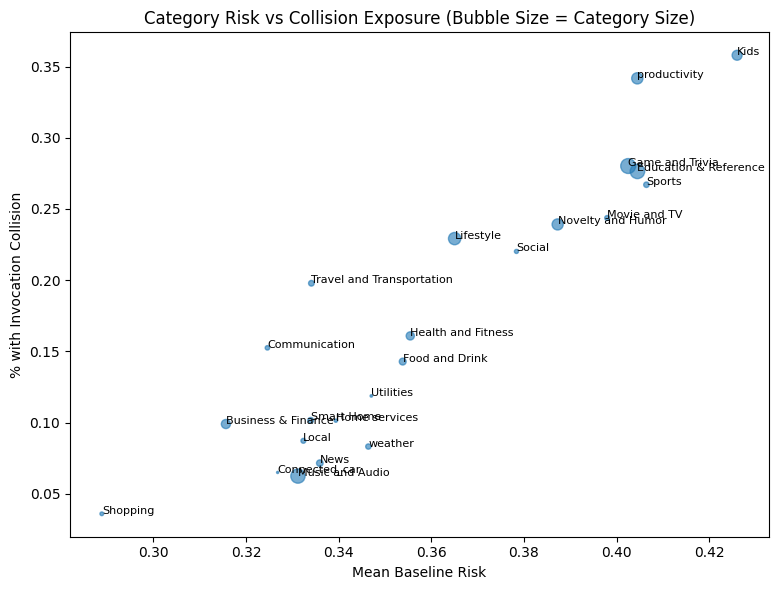

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("category_risk_summary.csv")

plt.figure(figsize=(8,6))

plt.scatter(
    df["mean_baseline_risk"],
    df["pct_with_exact_invocation_collision"],
    s=df["skill_count"] / 50,
    alpha=0.6
)

for i, row in df.iterrows():
    plt.text(row["mean_baseline_risk"], row["pct_with_exact_invocation_collision"], row["Category"], fontsize=8)

plt.xlabel("Mean Baseline Risk")
plt.ylabel("% with Invocation Collision")
plt.title("Category Risk vs Collision Exposure (Bubble Size = Category Size)")
plt.tight_layout()
plt.show()

## 10. Output Inventory

The main output for baseline comparison is `full_alexa_skills_with_baselines.csv`.

The main output for the next LLM step is `llm_analysis_subset.csv`.

The pair and cluster files are useful for sanity checks, examples, and report tables.

In [54]:
for path in [
    FULL_CLEANED_OUT,
    BASELINE_OUT,
    LLM_SUBSET_OUT,
    TOP_LEXICAL_PAIRS_OUT,
    TOP_PHONETIC_PAIRS_OUT,
    TOP_WORD_SQUAT_PAIRS_OUT,
    PHONETIC_CLUSTERS_OUT,
    CATEGORY_SUMMARY_OUT,
]:
    if path.exists():
        print(f"{path}: {path.stat().st_size / 1024 / 1024:.2f} MB")

full_cleaned_alexa_skills.csv: 36.65 MB
full_alexa_skills_with_baselines.csv: 48.74 MB
llm_analysis_subset.csv: 1.50 MB
top_lexical_pairs.csv: 0.88 MB
top_phonetic_pairs.csv: 0.93 MB
top_word_squat_pairs.csv: 5.02 MB
phonetic_clusters.csv: 0.19 MB
category_risk_summary.csv: 0.00 MB
